In [1]:
#Importing data set

from google.colab import files
uploaded = files.upload()

Saving athlete_events.csv.zip to athlete_events.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile("athlete_events.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
#used libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("athlete_events.csv")
print("Dataset Loaded")
print(df.shape)

Dataset Loaded
(271116, 15)


In [5]:
#Missing Values

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Height"] = df["Height"].fillna(df["Height"].median())
df["Weight"] = df["Weight"].fillna(df["Weight"].median())
df["Medal"] = df["Medal"].fillna("No Medal")

In [6]:
#Remove Duplicates

df = df.drop_duplicates()
print("After duplicate removal:", df.shape)

After duplicate removal: (269731, 15)


In [7]:
#Remove Outliers

num_cols = ["Age", "Height", "Weight"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After outlier removal:", df.shape)

After outlier removal: (238785, 15)


In [8]:
#data integration

df_model = df[[ "Age", "Height", "Weight", "Sport", "Medal"]].copy()
print("Integrated Data Shape:", df.shape)

Integrated Data Shape: (238785, 15)


In [9]:
#data tranformation

df_model["Medal"] = df_model["Medal"].map({
    "Gold":3,
    "Silver":2,
    "Bronze":1,
    "No Medal":0
})

In [10]:
#Remove Remaining NaN

df_model = df_model.dropna()

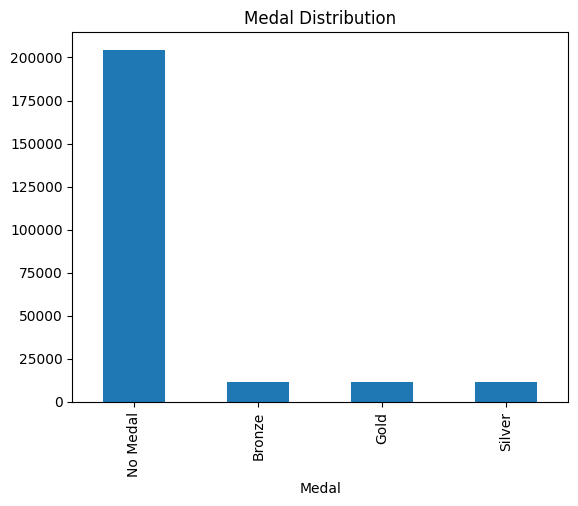

In [11]:
#daga analysis of medal distribution

df["Medal"].value_counts().plot(kind='bar')
plt.title("Medal Distribution")
plt.show()

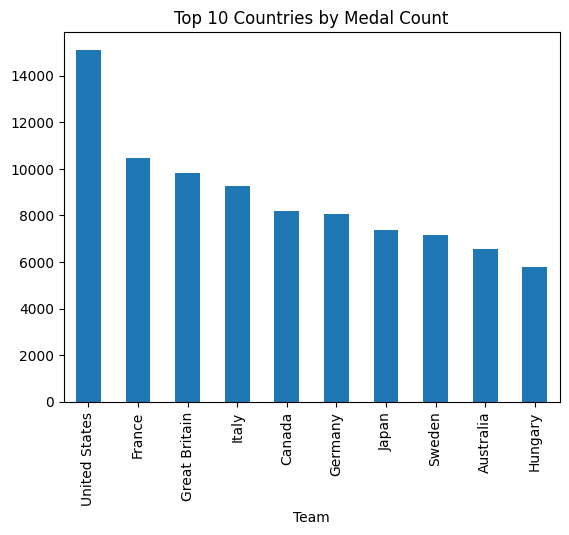

In [12]:
#top 10 countries analysis

country_medals = df.groupby("Team")["Medal"].count()

country_medals.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by Medal Count")
plt.show()

In [13]:
kmeans_architecture = pd.DataFrame({
    "Component": ["Input Layer","Features Used","Algorithm","No. of Clusters","Initialization","Max Iterations","Random State","Output"],
    "Description": ["Normalized Dataset","Age, Height, Weight","K-Means",
                    "3","K-Means++","300","42","Clustered Groups"]
})

kmeans_architecture

,Component,Description
0,Input Layer,Normalized Dataset
1,Features Used,"Age, Height, Weight"
2,Algorithm,K-Means
3,No. of Clusters,3
4,Initialization,K-Means++
5,Max Iterations,300
6,Random State,42
7,Output,Clustered Groups


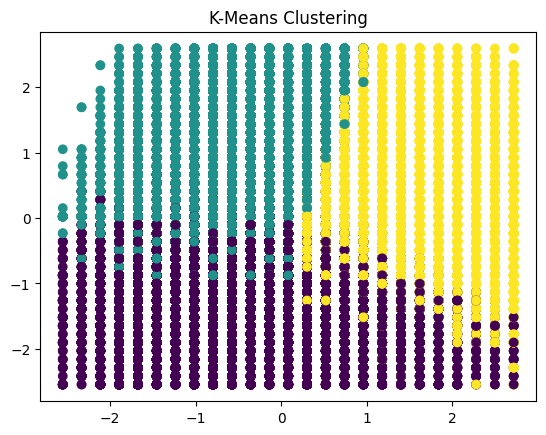

In [14]:
# K - Means clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X = df[['Age','Height','Weight']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("K-Means Clustering")
plt.savefig("Training_Config.png")
plt.show()

In [15]:
import pandas as pd

performance_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "Confusion Matrix"],
    "Description": [
        "Measures overall correctness of the model",
        "Measures correctly predicted positive values",
        "Measures correctly identified actual values",
        "Balance between Precision and Recall",
        "Shows TP, TN, FP, FN values"
    ]
})

performance_metrics

,Metric,Description
0,Accuracy,Measures overall correctness of the model
1,Precision,Measures correctly predicted positive values
2,Recall,Measures correctly identified actual values
3,F1-Score,Balance between Precision and Recall
4,Confusion Matrix,"Shows TP, TN, FP, FN values"


In [16]:
# Performance Metrics

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selecting Features (Input)
X = df[['Age','Height','Weight']]

# Converting Medal into Numeric Output
y = df['Medal'].map({
    "Gold":3,
    "Silver":2,
    "Bronze":1,
    "No Medal":0
})

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

MAE : 0.47916089958223373
MSE : 0.6507882107665799
RMSE : 0.8067144542938225
R2 Score : -0.10337937731356805


Silhouette Score: 0.33

Cluster Analysis:
                Age      Height     Weight
Cluster                                  
0        32.253004  174.228132  69.536865
1        24.391351  185.205766  83.534394
2        22.073536  167.231766  59.884706


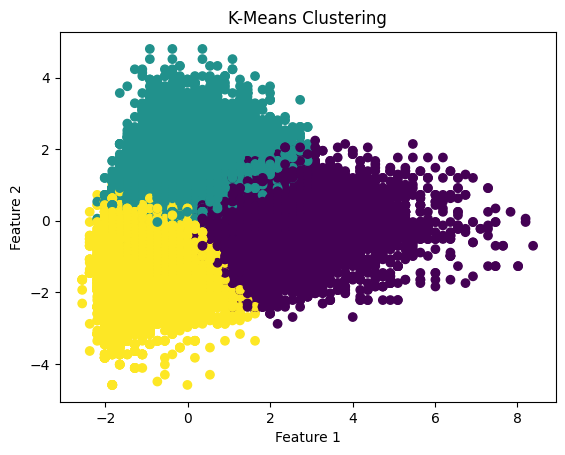

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 🔹 Load dataset
df = pd.read_csv("athlete_events.csv")

# 🔥 SELECT ONLY NUMERIC COLUMNS (AUTO FIX)
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# 🔹 Keep only useful columns (optional but recommended)
df_numeric = df_numeric[["Age", "Height", "Weight"]]

# 🔹 Remove missing values
df_numeric = df_numeric.dropna()

# 🔹 Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# 🔹 K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 🔹 Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score, 2))

# 🔹 Cluster Analysis
df_numeric["Cluster"] = clusters
print("\nCluster Analysis:\n", df_numeric.groupby("Cluster").mean())

# 🔹 Visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()